### 실습2. 다중 분류 문제 해결하기
- 분류 예측의 갯수가 3개 이상인 것
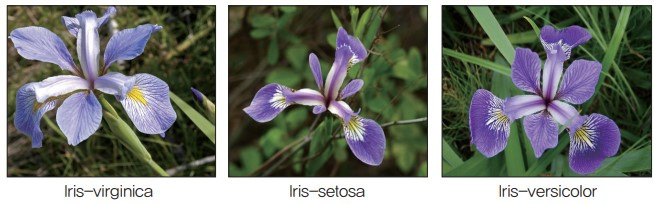
- 아이리스는 꽃잎의 모양과 길이에 따라 여러 가지 품종으로 나뉨
- 보면 품종마다 비슷해 보이는데요. 과연 딥러닝을 사용해서 이들을 구별해 낼 수 있을까?
### 붓꽃 데이터 구조
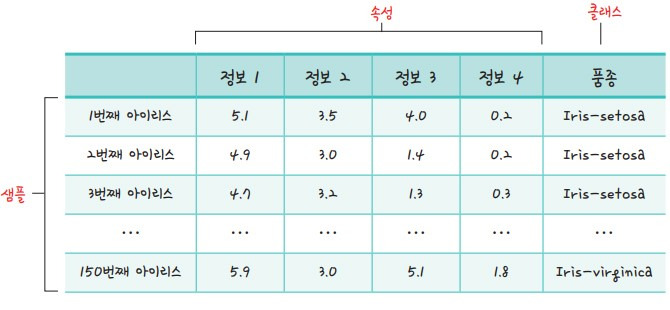
### feature 정보
- sepal length : 꽃받침 길이
- sepal width : 꽃받침 너비
- petal length : 꽃잎 길이
- petal width : 꽃잎 길이
### 데이터 준비

In [1]:
import pandas as pd

In [2]:
# 데이터 가져오기
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target  # 0,1,2

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
# DataFrame 생성
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 상관도 그래프 그리기

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

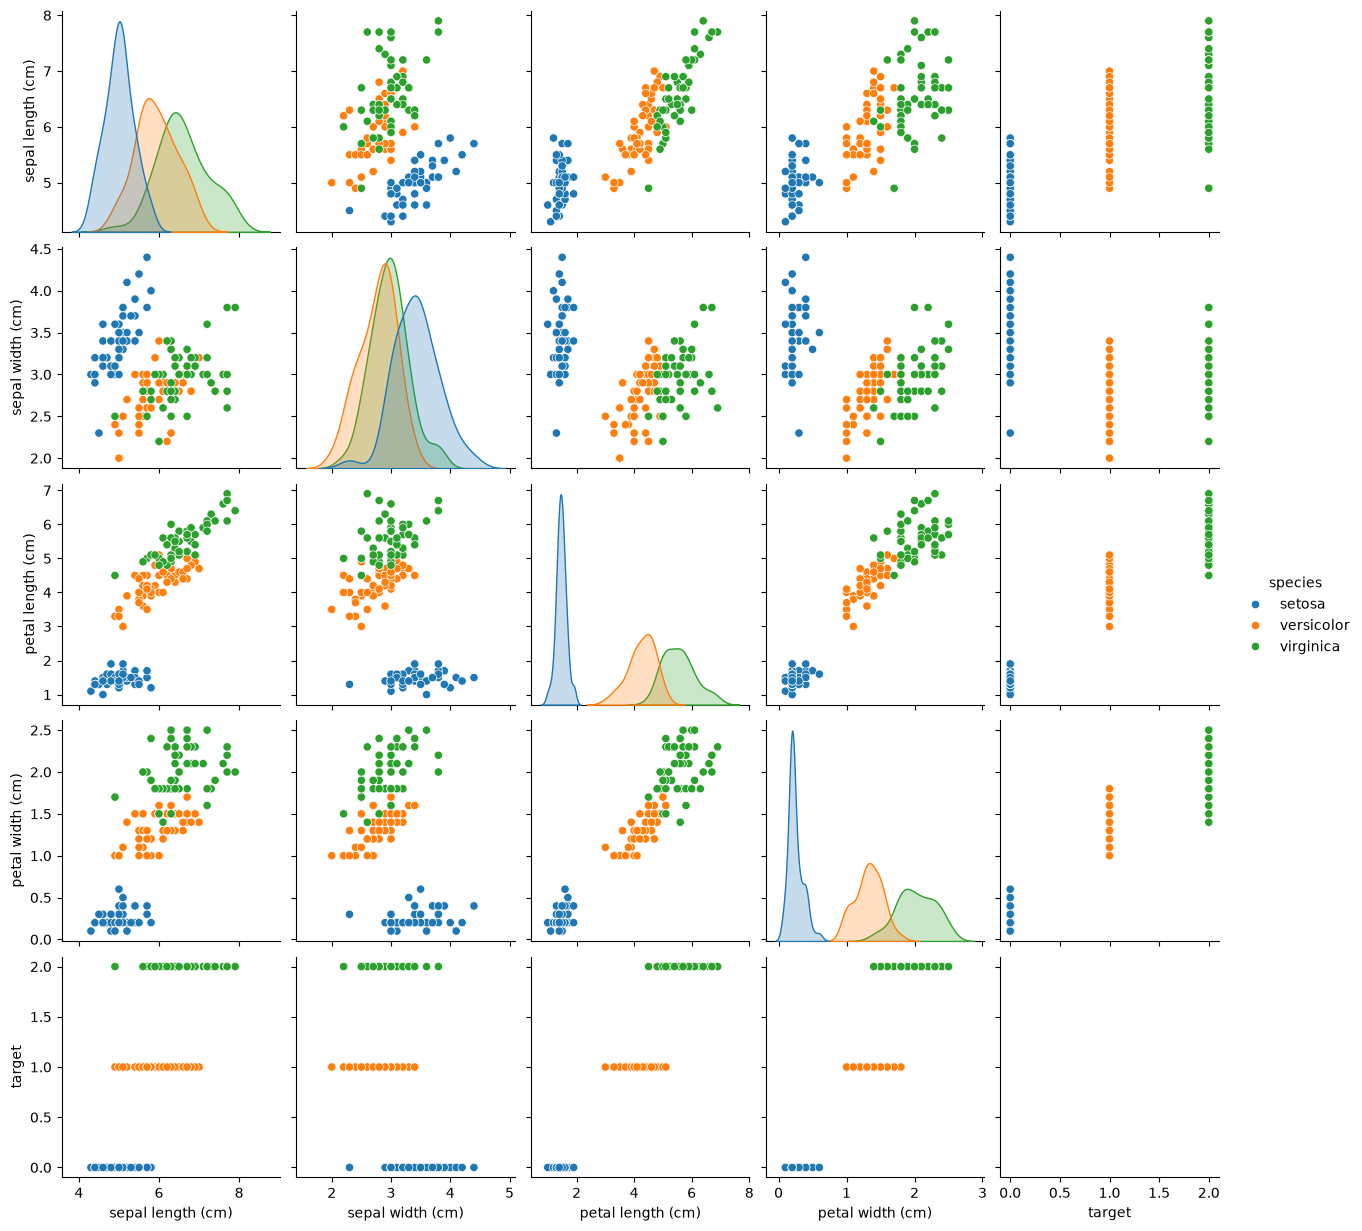

In [7]:
sns.pairplot(df, hue='species')
plt.show()

X, y 데이터 분할

In [8]:
# X데이터 
X = df.iloc[:, :4]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
y = df['target']

### 데이터 전처리

In [10]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

### 문자를 숫자형으로 바꾸기
- one-hot encoding(원핫인코딩)
- pd.get_dummies()

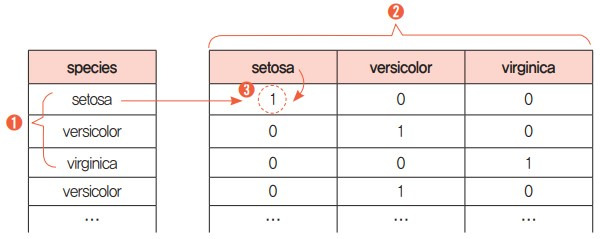

In [12]:
# 원핫인코딩 처리
y = pd.get_dummies(y)
print(y.head())

      0      1      2
0  True  False  False
1  True  False  False
2  True  False  False
3  True  False  False
4  True  False  False


### 학습/테스트 데이터 셋으로 분할

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=88,
    stratify=y
)

### 딥러닝 모델 만들기
#### 딥러닝 모델 구조 정의
- 출력층의 노드수 3개(setosa, versicolor, verginica), 다항 분류
- 활성함수(activation) : sfoftmax
- 컴파일(compile) : categorical_crossentropy

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

I0000 00:00:1788163714.123011 3795277 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788163714.163646 3795277 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788163712.648477 3795277 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### 모델 성능 최적화
- 가중치 최적화 알고리즘 : Adam
- learning_rate=0.001
- loss function = categorical_crossentropy
- metrics = accuracy

#### 모델 학습
- validation_split=0.2
- epochs=100
- batch_size=5

In [15]:
# 모델 객체 생성
# 입력 4
# 은닉층1 노드 12
# 은닉층2 노드 8
# 출력 3

model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(12, activation='relu', name='Dense_6'))
model.add(Dense(8, activation='relu', name='Dense_7'))
model.add(Dense(3, activation='softmax', name='Dense_8'))

model.summary()  # 딥러닝 모델 구조를 보여줌

I0000 00:00:1788163713.490589 3795277 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_6 (Dense)                 │ (None, 12)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_7 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

### 모델 컬파일

In [16]:
# 정의한 모델이 효과적으로 실행될 수 있도록, loss함수, 최적화 함수, 평가 방법 설정
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### 모델 학습

In [17]:
history = model.fit(X, y, epochs=100, batch_size=5, validation_split=0.2)

Epoch 1/100


I0000 00:00:1788163714.833734 3795400 service.cc:153] XLA service 0x799e64032530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788163714.833760 3795400 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788163714.847806 3795400 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788163714.947052 3795400 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788163714.953372 3795400 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1263__.17


 1/24 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.4000 - loss: 1.4016

I0000 00:00:1788163715.826151 3795400 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1417 - loss: 1.4831 - val_accuracy: 0.6000 - val_loss: 0.9725
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1250 - loss: 1.2462 - val_accuracy: 0.0000e+00 - val_loss: 1.3740
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4167 - loss: 1.1686 - val_accuracy: 0.0000e+00 - val_loss: 1.4277
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4167 - loss: 1.1097 - val_accuracy: 0.0000e+00 - val_loss: 1.4362
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4167 - loss: 1.0760 - val_accuracy: 0.0000e+00 - val_loss: 1.3027
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4167 - loss: 1.0298 - val_accuracy: 0.0000e+00 - val_loss: 1.3928
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4167 - loss: 1.0091 - val_accuracy: 0.0000e+00 - val_loss: 1.2610
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4167 - loss: 0.9860 - val_accurac

In [18]:
model.evaluate(X_test, y_test )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step - accuracy: 0.5667 - loss: 0.7549


[0.7549070715904236, 0.5666666626930237]

In [19]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

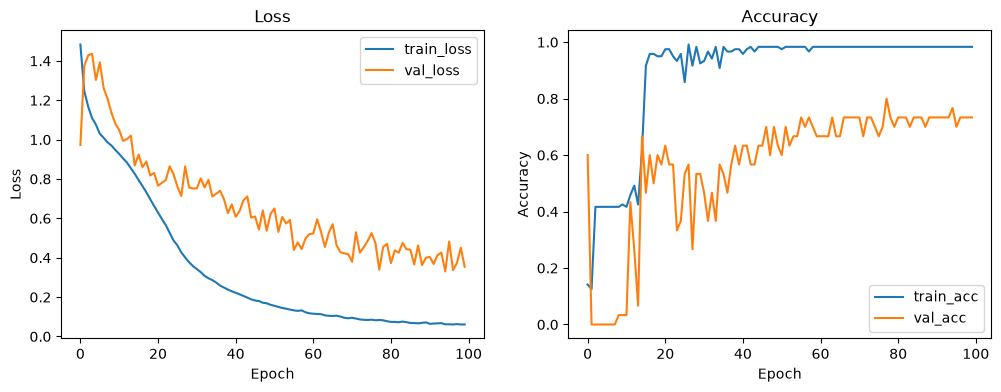

In [20]:
import matplotlib.pyplot as plt

# history는 model.fit()의 반환값
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

### Confusion Matrix

In [22]:
# X_test 데이터에 대한 확률값 예측
y_pred_proba = model.predict(X_test)

# 확률이 가장 높은 값의 위치 인덱스
y_pred = np.argmax(y_pred_proba, axis=1)

# y의 실제 값
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step

Confusion Matrix:
[[10  0  0]
 [ 9  1  0]
 [ 3  1  6]]


### 평가 레포트

In [23]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       0.45      1.00      0.62        10
  versicolor       0.50      0.10      0.17        10
   virginica       1.00      0.60      0.75        10

    accuracy                           0.57        30
   macro avg       0.65      0.57      0.51        30
weighted avg       0.65      0.57      0.51        30



In [24]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="macro"
)

print(roc_auc)

0.8733333333333334
